In [1]:
import os
os.getcwd()
import read_files
import pandas as pd
import torch

In [2]:
# 0) Imports
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1) Load model + tokenizer
model_name = "BabyLM-community/babylm-baseline-10m-gpt2"
# model_name = "BabyLM-community/babylm-baseline-10m-gpt2"

# model_name = "BabyLM-community/babylm-baseline-10m-gpt-bert-masked-focus"
# model_name = "BabyLM-community/babylm-baseline-10m-gpt-bert-mixed"
tokenizer = AutoTokenizer.from_pretrained(model_name,revision='main',trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name,revision='main',trust_remote_code=True)

# 2) Device + eval mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(16384, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=16384, bias=False)
)

if P(T_1|C_1) > P(T_2|C_1) -> 0.5
if P(T_2| C_2) > P(T_1|C_2) ->0.5 

Needed [BOS_Token, Tok1, Tok2,Tok3],

To predict [TokPred1, TokPred2, TokPred3, TokenPred4]

And then remove TokenPred4


P(T_1|C_1)/P(T_2|C_1) >  P(T_1|C_2)/P(T_2|C_2) 

Whethere The conditional likelihood of T_1|C_1 increases relative to T_1|C_2
If we change to 
P(T_1|C_1)/P(T_2|C_1) >  P(T_1|C_1)/P(T_2|C_1) 
then does it become more likely?

We Load the Dataset

In [1]:
import json
import os
from pathlib import Path

# Path to the EWOK datasets
ewok_fast_path = "/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"
ewok_filtered_path = "/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/full_eval/ewok_filtered"

def load_ewok_dataset(data_path, domain=None):
    """Load EWOK dataset from local files"""
    dataset = []
    
    if domain:
        # Load specific domain
        file_path = Path(data_path) / f"{domain}.jsonl"
        if file_path.exists():
            with open(file_path, 'r') as f:
                for line in f:
                    dataset.append(json.loads(line.strip()))
    else:
        # Load all domains
        for file_path in Path(data_path).glob("*.jsonl"):
            with open(file_path, 'r') as f:
                for line in f:
                    dataset.append(json.loads(line.strip()))
    
    return dataset

# Example usage:
# Load all domains from fast evaluation
ewok_fast_data = load_ewok_dataset(ewok_fast_path)
print(f"Fast eval dataset: {len(ewok_fast_data)} examples")



Fast eval dataset: 1100 examples


In [4]:

filtered_ewok_data = ewok_fast_data

We change the directory to be able to use the authors original source code.

In [5]:
import os
os.getcwd()
#default path is '/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot'
if os.getcwd() == '/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot':
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/') 
else:
    os.chdir('/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_pipeline/sentence_zero_shot')

In [6]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
import torch
import torch.nn.functional as F
# from torch.utils.data import DataLoader

import math
from collections import Counter, defaultdict
from tqdm import tqdm
import argparse


We get the authors dataloader. This was originally used to diagnose an issue I was having computing conditional log probabilities.

In [7]:
# Run the repo's exact pipeline codepaths inside the notebook (faithful reproduction)
from types import SimpleNamespace
from pathlib import Path
from evaluation_pipeline.sentence_zero_shot.dataset import get_dataloader
# from dataset import get_dataloader
args = SimpleNamespace(
    data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
    output_dir=Path("/tmp"),
    task="ewok",
    model_path_or_name=model_name,
    backend="causal",
    min_temperature=1.0,
    max_temperature=None,
    temperature_interval=0.05,
    batch_size=64,
    non_causal_batch_size=64,
    full_sentence_scores=False,
    save_predictions=True,
    revision_name="main",
)

dataloader = get_dataloader(args)
temperatures = [1.0]
tuple_of_stuff= next(iter(dataloader))
raw_sentences, sentence_dict, labels, metadatas, uids = tuple_of_stuff


An example of padded text.

In [8]:
tokenizer.decode(sentence_dict['sentence_1_inputs'][0])

'<s> Jesse applied pressure to the balloon. It remained intact. The balloon is fragile.<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>'

We build a dataframe with context C , targets T_1 & T_2, their conditional, target probabilities log(P(T_i|C)).

We wanted to determine if the model could correctly identify that  P(T_1|C_1) > P(T_1) and P(T_2|C_1) < P(T_2)

Result was that P(T_1|C_1) > P(T_1) 
                P(T_2|C_1) > P(T_2)

is the model saying that P(T_1|C) > P(T_1) in general for out of domain contexts?

In [9]:
#Building a dataframe with the sentences, context, targets, and log probabilities
j = 0
context_list = []
target_1_list = []
target_2_list = []
P_T1_C_list = []
P_T2_C_list = []
P_T1_list = []
P_T2_list = []
UID_list = []
concept_tested = { }
for raw_sentences, sentence_dict, labels, metadatas, uids in tqdm(dataloader):
    # target_probs = target_log_probs[j]
    # print(conditional_probs.shape)
    for i in range(len(raw_sentences)):
        context = raw_sentences[i]['prefixes'][0]
        context_list.append(context)
        target_1 = raw_sentences[i]['completions'][0]
        target_1_list.append(target_1)
        target_2 = raw_sentences[i]['completions'][1]
        target_2_list.append(target_2)
        
        # conditional_log_prob_pair = conditional_probs[i]
        # P_T1_C_list.append(conditional_log_prob_pair[0].item())
        # P_T2_C_list.append(conditional_log_prob_pair[1].item())
        # P_T1_list.append(target_probs[i][0])
        # P_T2_list.append(target_probs[i][1])
        UID_list.append(metadatas[i]['UID'])
        # concept_tested[context] = metadatas[i]['concept_tested']

    j += 1

df = pd.DataFrame({'UID':UID_list,'context': context_list, 'target_1': target_1_list, 'target_2': target_2_list})
df

100%|██████████| 18/18 [00:00<00:00, 43.22it/s]


,UID,context,target_1,target_2
0,material-properties,Jesse applied pressure to the balloon. It rema...,The balloon is sturdy.,The balloon is fragile.
1,material-properties,Chao cannot see through the wheel.,The wheel is opaque.,The wheel is transparent.
2,material-properties,The bin is made of jelly.,The bin is soft.,The bin is hard.
3,material-properties,The balloon is made of terracotta.,The surface of the balloon is hard.,The surface of the balloon is soft.
4,material-properties,The balloon weighs a lot.,The balloon is heavy.,The balloon is light.
...,...,...,...,...
1095,material-dynamics,Ali sees the propane.,Ali stirs it.,Ali drapes it.
1096,material-dynamics,Chao sees something that is liquid.,Chao stirs it.,Chao drapes it.
1097,material-dynamics,Mohammed sees the nitrogen.,Mohammed stirs it.,Mohammed squeezes it.
1098,material-dynamics,Chao sees the water.,It drips.,It breaks.


write custom function for computing estimated text likelihood. 

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
# Let's assume 'my-finetuned-gpt2' was trained with a BOS token
model_path = 'BabyLM-community/babylm-baseline-10m-gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_path) # Or your fine-tuned model
model = AutoModelForCausalLM.from_pretrained(model_path) # Or your fine-tuned model
context_1 = 'Jesse applied pressure to the balloon. It remained intact.'
target_1 = 'The balloon is sturdy.'
target_2 = 'The balloon is fragile.'
text = context_1 + " " + target_2
# print(tokenizer.bos_token)
def compute_log_likelihood(model, tokenizer, text,mean=False):
    # Prepend the BOS token to the text
    input_text = text

    # Tokenize the input
    inputs = tokenizer(input_text, add_special_tokens=False, return_tensors="pt")
    input_ids = inputs.input_ids
    length_of_text = len(input_ids[0])
    attn_mask = inputs.attention_mask
    bos_token_id = tokenizer.bos_token_id
    # bos_token_id = 236
    print(tokenizer.decode([236]))
    input_ids = torch.cat([torch.tensor([[bos_token_id]]), input_ids], dim=1)
    # print(tokenizer.decode(input_ids[0]))
    # input_ids = torch.cat([torch.tensor([tokenizer.bos_token_id]), input_ids[0]], dim=0)
    attn_mask = torch.cat([torch.tensor([1]), attn_mask[0]], dim=0)
    with torch.no_grad():
    # The model's output contains logits
        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        logits = outputs['logits']
        # print( 'logits shape ',logits.shape)
    # we remove the last token from the logits and the input ids, since it's not relevant for the log likelihood
    logits = logits[:,:-1,:]
    log_probs = torch.log_softmax(logits, dim=-1)
    # print('input_ids shape: ', input_ids.shape)
    # print('log_probs shape',log_probs.shape)
    # we remove the first token from the input ids, since it's the BOS token
    input_ids = input_ids[:,1:]
    #we remove the first token from the attention mask, since it's the BOS token
    attn_mask = attn_mask[1:]
    token_logprobs = log_probs.gather(dim=-1, index=input_ids.unsqueeze(-1)).squeeze(-1)
    # print('token_logprobs shape',token_logprobs.shape)
    total_log_prob = torch.sum(token_logprobs*attn_mask)
    # print(f"Log-likelihood with BOS: {total_log_prob.item()}")
    if mean == True:
        return total_log_prob.item()/length_of_text
    else:
        return total_log_prob.item()
compute_log_likelihood(model, tokenizer, text,mean=False) - compute_log_likelihood(model, tokenizer, context_1,mean=False)

-19.90595245361328

In [ ]:
# compute_log_likelihood(model, tokenizer,target_1)
def compute_conditional_log_likelihood(model, tokenizer, context, target, mean=False):
    text = context + " " + target
    if mean == True:
        target_token_length = len(tokenizer.encode(target,add_special_tokens=False))
        # print('target_token_length', target_token_length)
        return (compute_log_likelihood(model, tokenizer, text) - compute_log_likelihood(model, tokenizer, context))/target_token_length
    else:
        return compute_log_likelihood(model, tokenizer, text) - compute_log_likelihood(model, tokenizer, context)

print('target_2', target_2)
print(tokenizer.decode(tokenizer.encode(target_2,add_special_tokens=False)))
compute_conditional_log_likelihood(model, tokenizer, context_1, target_2,mean=True)




target_2 The balloon is fragile.
The balloon is fragile.




-3.3176587422688804

we gather all available domains.

In [18]:
domains = df['UID'].unique()
print(domains)

['material-properties' 'social-interactions' 'social-relations'
 'spatial-relations' 'quantitative-properties' 'physical-dynamics'
 'agent-properties' 'social-properties' 'physical-relations'
 'physical-interactions' 'material-dynamics']


In [19]:
#Determining if a target sentence becomes more likely only because it was given a context
#rather than the context changing the meaning of the sentence
import numpy as np
out_of_domain_context_impact = {'domain':[],'P(T|C)':[],'P(T|C) std':[],'P(T)':[], 'P(T) std':[],'P(T_1|C) > P(T_1)':[]}
domain_context_pairs = {'C':[],'T':[],'T domain':[],'C domain': [],'P(T|C)':[],'P(T)':[]}

for domain in domains:
    compute_mean = True
    domain_df = df[df['UID'] == domain]
    out_of_domain_df = df[df['UID'] != domain]
    target_1_sentences = domain_df['target_1'].values
    context_1_sentences = out_of_domain_df['context'].values
    random_context_likelihoods = []
    target_sentence_likelihoods = []
    out_of_domain_context_impact['domain'].append(domain)
    times_context_impact_greater_than_target_likelihood = 0
    samples_per_target = 5
    for target in target_1_sentences:
        for j in range(samples_per_target):
            random_index = np.random.randint(0,len(context_1_sentences))
            random_context = context_1_sentences[random_index]
            #compute P(T|C)
            random_context_likelihoods.append(compute_conditional_log_likelihood(model, tokenizer, random_context, target,mean=compute_mean))
            #compute P(T)
            target_sentence_likelihoods.append(compute_log_likelihood(model, tokenizer, target,mean=compute_mean))
            if random_context_likelihoods[-1] > target_sentence_likelihoods[-1]:
                times_context_impact_greater_than_target_likelihood += 1
            #we give info on the specific target and context pair that was used to compute the likelihoods
            #and their probabilities. This will be used to analyze pairs where domain differs a lot versus a little
            domain_context_pairs['T'].append(target)
            domain_context_pairs['T domain'].append(domain)
            domain_context_pairs['C'].append(random_context)
            domain_context_pairs['C domain'].append(out_of_domain_df['UID'].values[random_index])
            domain_context_pairs['P(T|C)'].append(random_context_likelihoods[-1])
            domain_context_pairs['P(T)'].append(target_sentence_likelihoods[-1])
    #Perform more broad analysis on the out of domain context impact
    out_of_domain_context_impact['P(T|C)'].append(np.mean(random_context_likelihoods))
    out_of_domain_context_impact['P(T|C) std'].append(np.std(random_context_likelihoods))
    out_of_domain_context_impact['P(T)'].append(np.mean(target_sentence_likelihoods))
    out_of_domain_context_impact['P(T) std'].append(np.std(target_sentence_likelihoods))
    out_of_domain_context_impact['P(T_1|C) > P(T_1)'].append(times_context_impact_greater_than_target_likelihood/(len(target_1_sentences)*samples_per_target))

We construct a dataframe containing the context, target_pairs

In [20]:
out_of_domain_context_target_df = pd.DataFrame(domain_context_pairs)
PMI = out_of_domain_context_target_df['P(T|C)'] - out_of_domain_context_target_df['P(T)']


In [21]:
#We check the bottom 5% of the PMI distribution
np.percentile(PMI.values,5)

-0.4435450962611605

In [22]:
#We check the top 5% of the PMI distribution
np.percentile(PMI.values,95)


1.4262094130882852

In [23]:
# we look at context target pairs where the PMI is below the 5th percentile
context_target_df = out_of_domain_context_target_df[PMI < np.percentile(PMI.values,5)]
context_target_df


,C,T,T domain,C domain,P(T|C),P(T)
11,Jesse is being dismissive towards Alex.,The bin is soft.,material-properties,social-interactions,-6.102934,-5.449194
40,Mohammed thinks having neighbors of a differen...,The wheel is bouncy.,material-properties,social-properties,-6.607724,-6.088756
52,Mohammed receives salary from Carmen.,The bin is bouncy.,material-properties,social-relations,-6.694237,-6.027950
111,Mohammed thinks having neighbors of a differen...,The wheel is bouncy.,material-properties,social-properties,-6.607724,-6.088756
117,Chao will be successful if Chao and Yan run in...,The bin is light.,material-properties,social-interactions,-6.104095,-5.424379
...,...,...,...,...,...,...
5292,The wheel is heavy.,Chao wrinkles it.,material-dynamics,physical-dynamics,-6.290276,-5.792805
5294,The football is moving forward on a surface. T...,Chao wrinkles it.,material-dynamics,physical-dynamics,-6.414552,-5.792805
5428,Maria spent the whole conversation talking abo...,Chao pours it.,material-dynamics,social-properties,-6.449378,-5.812833
5448,The train can completely hide the boulder from...,Li drapes it.,material-dynamics,physical-relations,-8.084647,-7.475646


In [24]:
context_target_df = out_of_domain_context_target_df[PMI > np.percentile(PMI.values,95)]
context_target_df






,C,T,T domain,C domain,P(T|C),P(T)
23,The nail is moving closer to the magnet.,The balloon is heavy.,material-properties,physical-interactions,-3.483043,-4.931505
24,The balloon is about to stop. Why?,The balloon is heavy.,material-properties,physical-dynamics,-2.566966,-4.931505
43,The nail is north of the wheel.,The wheel is bouncy.,material-properties,spatial-relations,-3.914110,-6.088756
60,Chao is less hesitant to play pool than to pla...,The football is bouncy.,material-properties,agent-properties,-5.151654,-6.926082
73,"In a moment, the top of the volleyball will re...",The surface of the volleyball is hard.,material-properties,physical-dynamics,-2.431462,-3.899599
...,...,...,...,...,...,...
5394,The bin's temperature is lower than Mohammed's...,Mohammed pours it.,material-dynamics,material-properties,-4.479973,-6.050182
5407,Chao hates Yan more than Ali.,Chao stirs it.,material-dynamics,agent-properties,-4.355735,-6.034016
5441,The gallery is south of Mohammed. Mohammed rea...,Mohammed stirs it.,material-dynamics,spatial-relations,-3.764230,-5.886751
5444,Mohammed hates Carmen.,Mohammed stirs it.,material-dynamics,social-relations,-4.153917,-5.886751


Displaying histogram with normal distribution fit (mean=0.44, std=0.56)...


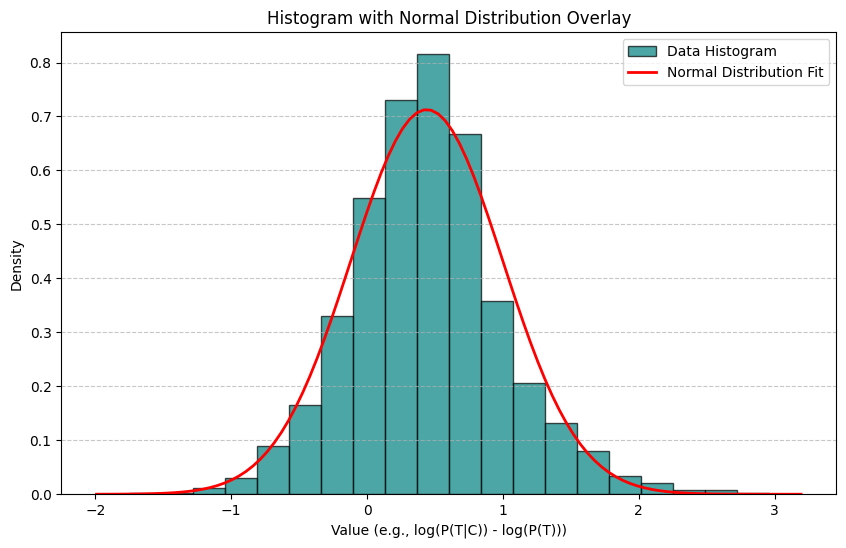

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats  # Added for normal distribution calculation

def plot_histogram_from_array(values_array):
    """
    Takes a NumPy array or list of numerical values and plots a histogram
    with a normal distribution overlay.

    Args:
        values_array: A list or NumPy array of numbers.
    """
    if values_array is None or len(values_array) == 0:
        print("The input array is empty. Cannot plot a histogram.")
        return

    # --- Calculate statistics for the normal distribution fit ---
    mu = np.mean(values_array)
    sigma = np.std(values_array)

    plt.figure(figsize=(10, 6))

    # The core plotting function, with `density=True` to normalize the histogram
    # so it can be compared to the probability density function.
    plt.hist(values_array, bins=20, density=True, color='teal', edgecolor='black', alpha=0.7, label='Data Histogram')

    # --- Plot the normal distribution curve ---
    # Create a range of x-values to plot the curve smoothly
    x_min, x_max = plt.xlim()
    x = np.linspace(x_min, x_max, 100)
    # Calculate the probability density function (PDF) for these x-values
    p = stats.norm.pdf(x, mu, sigma)
    # Plot the PDF as a red line
    plt.plot(x, p, 'r-', linewidth=2, label='Normal Distribution Fit')

    plt.title('Histogram with Normal Distribution Overlay')
    plt.xlabel('Value (e.g., log(P(T|C)) - log(P(T)))')
    plt.ylabel('Density')  # Y-axis is now density, not frequency
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    print(f"Displaying histogram with normal distribution fit (mean={mu:.2f}, std={sigma:.2f})...")
    plt.show()


# Just call the function with your array.
plot_histogram_from_array(PMI.values)


In [26]:
out_of_domain_context_impact_df = pd.DataFrame(out_of_domain_context_impact)
out_of_domain_context_impact_df

,domain,P(T|C),P(T|C) std,P(T),P(T) std,P(T_1|C) > P(T_1)
0,material-properties,-4.635700,0.948275,-5.046823,0.790307,0.754
1,social-interactions,-6.559971,1.129493,-6.810215,0.855530,0.666
2,social-relations,-5.975205,0.873070,-6.020691,0.647270,0.508
3,spatial-relations,-5.017935,1.262631,-5.574497,1.166611,0.886
4,quantitative-properties,-4.680701,0.848897,-5.246804,0.858041,0.940
5,physical-dynamics,-5.008164,0.905572,-5.634088,0.730153,0.830
6,agent-properties,-5.286095,0.941157,-5.630185,0.922076,0.832
7,social-properties,-5.792266,0.988263,-6.317830,0.846211,0.840
8,physical-relations,-4.350647,0.690960,-4.876183,0.603112,0.890
9,physical-interactions,-5.180691,0.888653,-5.655723,0.756841,0.810


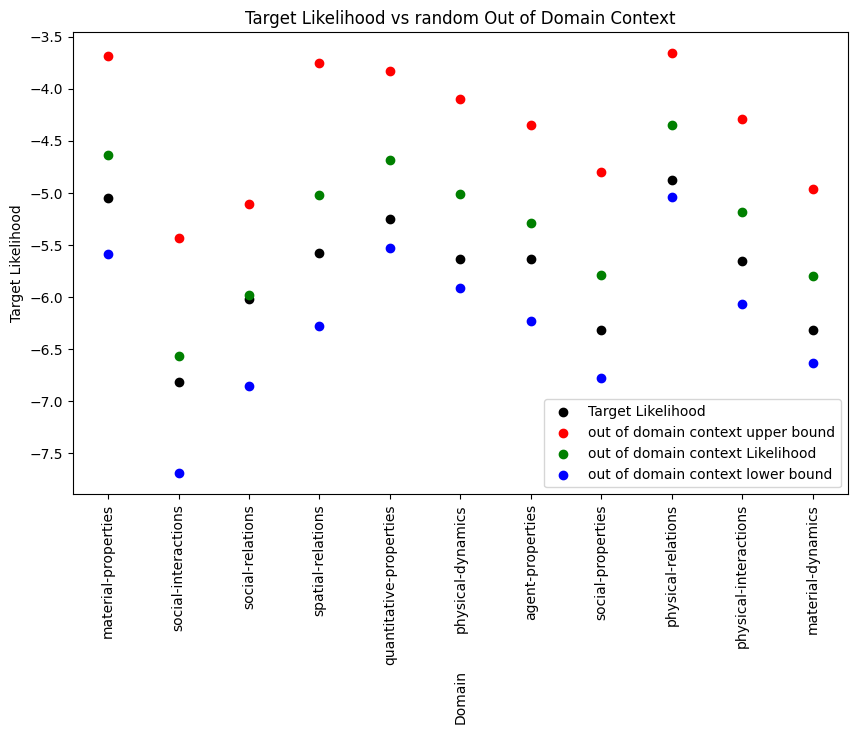

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(out_of_domain_context_impact['domain'],out_of_domain_context_impact_df['P(T)'],color='black',label='Target Likelihood')
plt.scatter(out_of_domain_context_impact['domain'],out_of_domain_context_impact_df['P(T|C)'] + out_of_domain_context_impact_df['P(T|C) std'],color='red',label='out of domain context upper bound')
plt.scatter(out_of_domain_context_impact['domain'],out_of_domain_context_impact_df['P(T|C)'] ,color='green',label='out of domain context Likelihood')

plt.scatter(out_of_domain_context_impact['domain'],out_of_domain_context_impact_df['P(T|C)'] - out_of_domain_context_impact_df['P(T|C) std'],color='blue',label='out of domain context lower bound')

plt.xlabel('Domain',rotation=90)
plt.ylabel('Target Likelihood')
plt.xticks(rotation=90)
plt.title('Target Likelihood vs random Out of Domain Context')
plt.legend()
plt.show()


In [28]:
#Determining if a target sentence becomes more likely only because it was given a context
#rather than the context changing the meaning of the sentence
import numpy as np
in_domain_context_impact = {'domain':[],'P(T|C)':[],'P(T|C) std':[],'P(T)':[],'P(T) std':[],'P(T_1|C) > P(T_1)':[]}

for domain in domains:
    domain_df = df[df['UID'] == domain]
    compute_mean = True
    context_1_sentences = domain_df['context'].values
    target_1_sentences = domain_df['target_1'].values
    random_context_likelihoods = []
    target_sentence_likelihoods = []
    in_domain_context_impact['domain'].append(domain)
    times_context_impact_greater_than_target_likelihood = 0
    samples_per_target = 5
    for target in target_1_sentences:
        for j in range(samples_per_target):
            random_context = context_1_sentences[np.random.randint(0,len(context_1_sentences))]
            random_context_likelihoods.append(compute_conditional_log_likelihood(model, tokenizer, random_context, target,mean=compute_mean))
            target_sentence_likelihoods.append(compute_log_likelihood(model, tokenizer, target,mean=compute_mean))
            if random_context_likelihoods[-1] > target_sentence_likelihoods[-1]:    
                times_context_impact_greater_than_target_likelihood += 1
    in_domain_context_impact['P(T|C)'].append(np.mean(random_context_likelihoods))
    in_domain_context_impact['P(T|C) std'].append(np.std(random_context_likelihoods))
    in_domain_context_impact['P(T)'].append(np.mean(target_sentence_likelihoods))
    in_domain_context_impact['P(T) std'].append(np.std(target_sentence_likelihoods))
    in_domain_context_impact['P(T_1|C) > P(T_1)'].append(times_context_impact_greater_than_target_likelihood/(len(target_1_sentences)*samples_per_target))
in_domain_context_impact_df = pd.DataFrame(in_domain_context_impact)
in_domain_context_impact_df


,domain,P(T|C),P(T|C) std,P(T),P(T) std,P(T_1|C) > P(T_1)
0,material-properties,-4.216532,0.922325,-5.046823,0.790307,0.952
1,social-interactions,-6.088547,1.113386,-6.810215,0.855530,0.854
2,social-relations,-5.546505,0.797433,-6.020691,0.647270,0.810
3,spatial-relations,-4.672079,1.295549,-5.574497,1.166611,0.950
4,quantitative-properties,-4.374207,0.886437,-5.246804,0.858041,0.996
5,physical-dynamics,-4.136349,0.826438,-5.634088,0.730153,1.000
6,agent-properties,-5.090565,0.986975,-5.630185,0.922076,0.916
7,social-properties,-5.803564,0.968897,-6.317830,0.846211,0.824
8,physical-relations,-3.895428,0.730167,-4.876183,0.603112,0.984
9,physical-interactions,-4.849581,0.896432,-5.655723,0.756841,0.956


In [29]:
print('random_context_likelihoods', np.mean(random_context_likelihoods),'standard deviation',np.std(random_context_likelihoods))
print('target_sentence_likelihoods ',np.mean(target_sentence_likelihoods),'standard deviation',np.std(target_sentence_likelihoods))

random_context_likelihoods -5.428716527766273 standard deviation 0.7179527185959447
target_sentence_likelihoods  -6.313697132292247 standard deviation 0.5469621981697932


In [30]:
#Determining if a target sentence becomes more likely only because it was given a context
#rather than the context changing the meaning of the sentence
import numpy as np
in_domain_context_impact = {'domain':[],'context_impact':[],'context_impact_std':[],'target_likelihood':[],'target_likelihood_std':[],'P(T_1|C) > P(T_1)':[]}

for domain in domains:
    domain_df = df[df['UID'] == domain]
    compute_mean = False
    context_1_sentences = domain_df['context'].values
    target_1_sentences = domain_df['target_1'].values
    random_context_likelihoods = []
    target_sentence_likelihoods = []
    in_domain_context_impact['domain'].append(domain)
    times_context_impact_greater_than_target_likelihood = 0
    samples_per_target = 5
    for target in target_1_sentences:
        for j in range(samples_per_target):
            random_context = context_1_sentences[np.random.randint(0,len(context_1_sentences))]
            random_context_likelihoods.append(compute_conditional_log_likelihood(model, tokenizer, random_context, target,mean=compute_mean))
            target_sentence_likelihoods.append(compute_log_likelihood(model, tokenizer, target,mean=compute_mean))
            if random_context_likelihoods[-1] > target_sentence_likelihoods[-1]:    
                times_context_impact_greater_than_target_likelihood += 1
    in_domain_context_impact['context_impact'].append(np.mean(random_context_likelihoods))
    in_domain_context_impact['context_impact_std'].append(np.std(random_context_likelihoods))
    in_domain_context_impact['target_likelihood'].append(np.mean(target_sentence_likelihoods))
    in_domain_context_impact['target_likelihood_std'].append(np.std(target_sentence_likelihoods))
    in_domain_context_impact['P(T_1|C) > P(T_1)'].append(times_context_impact_greater_than_target_likelihood/(len(target_1_sentences)*samples_per_target))
in_domain_context_impact_df = pd.DataFrame(in_domain_context_impact)
in_domain_context_impact_df

,domain,context_impact,context_impact_std,target_likelihood,target_likelihood_std,P(T_1|C) > P(T_1)
0,material-properties,-28.877248,6.508968,-34.461857,5.426969,0.952
1,social-interactions,-42.691747,6.723903,-48.438672,6.073732,0.898
2,social-relations,-43.100859,6.437092,-46.730347,6.236011,0.808
3,spatial-relations,-37.518175,6.649640,-45.680179,5.064311,0.958
4,quantitative-properties,-33.573287,10.469231,-39.956465,11.193445,0.994
5,physical-dynamics,-24.351996,5.178685,-32.943835,4.456582,1.000
6,agent-properties,-61.640273,15.589040,-68.299392,15.330593,0.918
7,social-properties,-31.368115,4.940756,-33.898063,4.664021,0.792
8,physical-relations,-29.028109,4.849227,-36.561539,3.652690,0.972
9,physical-interactions,-37.345072,5.443246,-44.336719,4.754277,0.958


In [31]:
print('random_context_likelihoods', np.mean(random_context_likelihoods),'standard deviation',np.std(random_context_likelihoods))
print('target_sentence_likelihoods ',np.mean(target_sentence_likelihoods),'standard deviation',np.std(target_sentence_likelihoods))


random_context_likelihoods -29.103037139892578 standard deviation 6.249188187253435
target_sentence_likelihoods  -33.57939891815185 standard deviation 6.4591030958648314


In [32]:
# # Prepend the BOS token to the text
# input_text = 'Ali sees the juice.'	+ ' It drips.'	
# print(input_text)
# # Tokenize the input
# print('input_text',input_text)
# inputs = tokenizer(input_text, return_tensors="pt")
# print(tokenizer.decode(inputs.input_ids[0]))
# print(inputs.attention_mask)
# print(inputs.input_ids.shape)
# with torch.no_grad():
#     outputs = model(input_ids=inputs.input_ids,labels=inputs.input_ids)
#     loss = outputs.loss * (inputs.input_ids.shape[1]-1 )
#     print(f'Calculated loss: {loss.item()}')
    

In [33]:
# Run the repo's exact pipeline codepaths inside the notebook (faithful reproduction)
from types import SimpleNamespace
from pathlib import Path
from evaluation_pipeline.sentence_zero_shot.dataset import get_dataloader
# from dataset import get_dataloader
from evaluation_pipeline.sentence_zero_shot.compute_results import compute_results
# from compute_results import compute_results
# from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report
from evaluation_pipeline.sentence_zero_shot.run import process_results, create_evaluation_report

args = SimpleNamespace(
    data_path=Path("/home/jorge/tokenPred/babylm_10m/test_eval/evaluation-pipeline-2025/evaluation_data/fast_eval/ewok_fast"),
    output_dir=Path("/tmp"),
    task="ewok",
    model_path_or_name=model_name,
    backend="causal",
    min_temperature=1.0,
    max_temperature=None,
    temperature_interval=0.05,
    batch_size=64,
    non_causal_batch_size=64,
    full_sentence_scores=False,
    save_predictions=False,
    revision_name="main",
)

dataloader = get_dataloader(args)
temperatures = [1.0]
results, _ = compute_results(args, model, dataloader, temperatures)
accuracies, average_accuracies = process_results(args, results)
create_evaluation_report(1.0, average_accuracies[1.0], accuracies[1.0])


  0%|          | 0/18 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument index in method wrapper_CUDA__index_select)